In [59]:
import seaborn as sn 
import pandas as pd 
import numpy as np
import warnings 
warnings.filterwarnings('ignore')

In [60]:
df = pd.read_csv('gym_members_exercise_tracking.csv')
df

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [62]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


In [63]:
df.shape

(973, 15)

In [64]:
df.isnull().sum()

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

In [65]:
print(df['Workout_Type'].unique())

['Yoga' 'HIIT' 'Cardio' 'Strength']


<Axes: xlabel='Calories_Burned', ylabel='Count'>

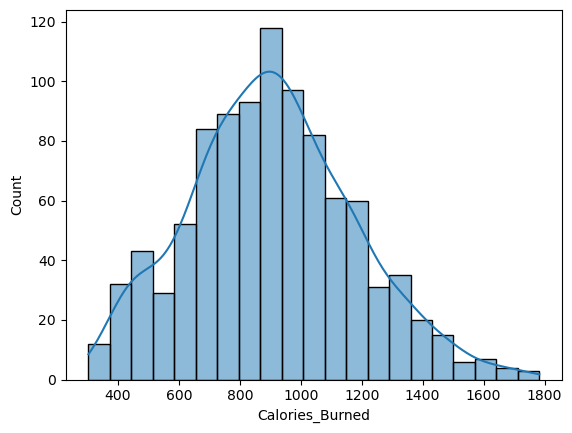

In [66]:
# checking target columns skewness

sn.histplot(df['Calories_Burned'], kde =  True , palette='rainbow')

In [67]:
print(df['Calories_Burned'].skew())

0.2783210950013363


Axes(0.125,0.11;0.62x0.77)


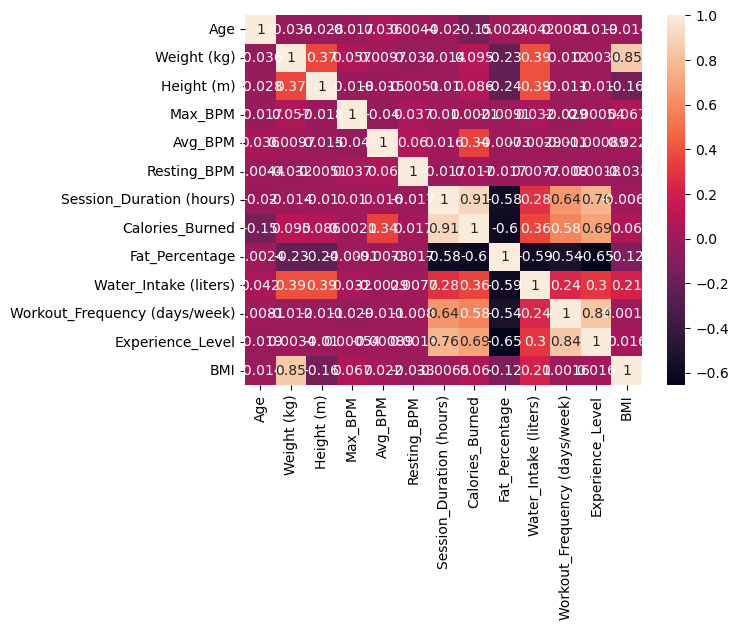

In [68]:
corr = sn.heatmap(df.corr(numeric_only = True), annot=True)
print(corr)

In [69]:
# Encoding 
df['Gender'] = df['Gender'].map({'male' : 0 , 'Female' : 1})

# One Hot Encode 
df = pd.get_dummies(df , columns=['Workout_Type'])

In [70]:
X = df.drop('Calories_Burned', axis = 1)
y = df['Calories_Burned']

In [71]:
from sklearn.model_selection import train_test_split

In [72]:
 X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

In [73]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [74]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test) # to pervent from data leakage 


In [79]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [83]:
import numpy as np

print(np.isnan(X_train).sum())

414


In [84]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [ ]:
# X_train = X_train[~np.isnan(X_train).any(axis=1)] -> To fill na values 

In [85]:
model.fit( X_train, y_train )

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [94]:
y_pred = model.predict(X_test)
print(y_pred)

[ 842.50062464 1369.97098472  914.48159641 1086.48049418 1427.2381773
 1275.28259558  920.41211675  895.13702611 1010.13092776 1144.77448295
 1311.09856001  694.66800192  812.51724502  773.89702328  772.84865727
  694.82187676  920.14860727 1120.8559154   943.01511813  492.06956394
  903.52113718  782.12274937  827.63499426  875.98085228  478.71796866
  760.5796232   935.97670197  447.38388895  961.20378623 1102.3313751
  822.88736065  927.71611193  604.40173689 1142.11827251 1231.86895905
 1416.51534471  692.1334853   940.03019367  634.9649993   478.19637301
  388.1138251   713.10985816  370.63523772  649.64867501  884.47598659
  956.39299099  749.9484355   866.12681036  759.04180762  960.05029052
  951.20299446 1136.63486234 1009.46292795 1218.77748251  797.78646912
 1332.83025749  717.06138125  485.42406253  467.51009848  722.86301841
  602.41300046  989.47504712 1269.91171708 1185.25892873  899.33057763
  870.66788415  605.42808586 1027.6273754   957.72515072 1213.94710277
 1513.94

In [89]:
from sklearn.metrics import r2_score ,mean_absolute_error , mean_squared_error

In [95]:
r2_score(y_test , y_pred)

0.9681399223931701